# Interpolation entre mesures de probabilités
 By Victor Ducros & Georgii Potoshin

# 1. Interpolation(s) entre deux mesures de probabilités


Le premier façons d'interpoler et en variables aleatoires. Donc on pose pour $X_0 \sim \mu_0$, $X_1 \sim \mu_1$ v.a.i. $X_t :=(1-t)X_0+tX_1$.


[T1] Si $X_0$ et $X_1$ admettent des densités $f_0$ et $f_1$, une question naturelle est de calculer la densité de $X_t$.

En passant par la méthode de la fonction muette, on prend $g$ une fonction continue bornée :
$$
\mathbb{E}(g(X_t)) = \mathbb{E}(g(h(X_0, X_1))) \quad \text{où } h(x_0, x_1) = (1 - t)x_0 + t x_1.
$$

Donc, par indépendance de $X_0$ et $X_1$ :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \int_{\mathbb{R}} g((1 - t)x_0 + t x_1) \, f(x_0) \, f(x_1) \, dx_0 \, dx_1.
$$

On effectue le changement de variable : $x = (1 - t)x_0 + t x_1$, en $x_0$ fixé.

On a :
$$
x_1 = \frac{1}{t} \left( x - (1 - t)x_0 \right),
$$
$$
dx = t \, dx_1 \quad \Rightarrow \quad dx_1 = \frac{dx}{t}.
$$

Donc :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \left( \int_{\mathbb{R}} g(x) \, f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) \frac{dx}{t}.
$$

Ce qui peut s'écrire :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} g(x) \left( \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) dx.
$$

Donc, par définition, la densité $f_t(x)$ est donnée par :
$$
f_t(x) = \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \quad \forall x \in \mathbb{R}.
$$
Cette densité est valable $\forall t \in ]0,1]$. Si $t=0$, on a $f_t=f_0$

[S1] Nous pouvons ainsi visualiser des densités pour differentes lois $X_0$ et $X_1$.

In [43]:
import numpy as np
import matplotlib as mplib
import matplotlib.pyplot as plt
import numpy.random as npr
import scipy.stats as sps
import scipy.integrate as spi
from scipy.stats import norm, uniform
from scipy.interpolate import CubicSpline

class Context:
    Lx: np.ndarray
    Lt: list[float]
    axes: mplib.axes._axes.Axes
    plt_count: int
    grid_width: int
    is_making_legend: bool

    def __init__(self, Lx: np.ndarray, Lt: list[float], a=1, b=3):
        self.Lx = Lx
        self.Lt = Lt
        self.plt_count = 0
        self.is_making_legend = True
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
        self.axes = axes.ravel()

    def next_axe(self):
        ax = self.axes[self.plt_count]
        self.plt_count += 1
        return ax

    def reset(self, a=1, b=3):
        self.plt_count = 0
        self.grid_width = b
        fig, axes = plt.subplots(a, b, figsize=(18, 5))
        self.axes = axes.ravel()

    def end_axe(self, ax, name):
        ax.grid(True, alpha=0.3)
        ax.set_title(name)
        if self.is_making_legend:
            ax.legend(loc="upper right", fontsize=8)

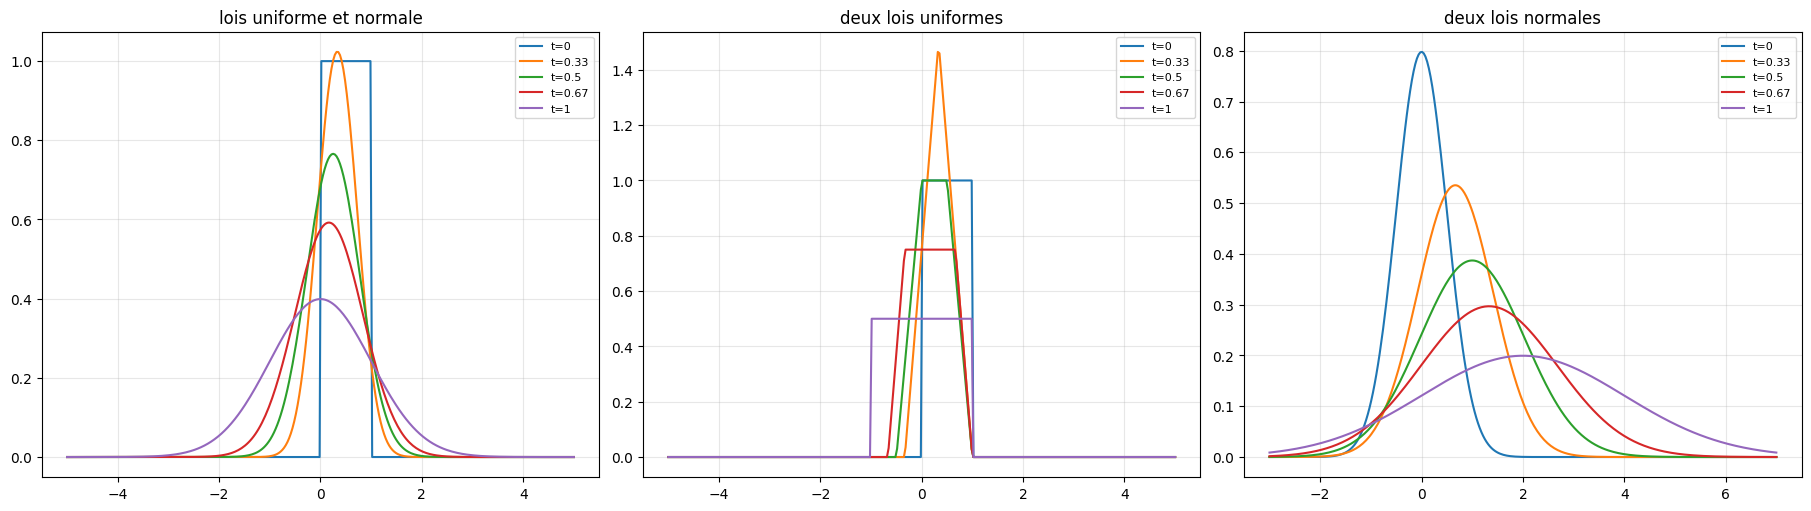

In [44]:
ctx = Context(
    np.linspace(-5,5,300),
    [0,1/3,1/2,2/3,1],
)

def va_inter(ctx, f, g, name, a=-np.inf, b=+np.inf):
    ax = ctx.next_axe()
    ax.plot(ctx.Lx, f.pdf(ctx.Lx),label="t=0")
    for t in ctx.Lt[1:]:
        integrale, _ = spi.quad_vec(lambda x0: f.pdf(x0)*g.pdf((ctx.Lx-(1-t)*x0)/t), a, b)
        res = (1/t) * integrale
        ax.plot(ctx.Lx, res, label="t=" + str(round(t, 2)))
    ctx.end_axe(ax, name)


va_inter(ctx, uniform, norm, "lois uniforme et normale", a=0, b=1)
va_inter(ctx, uniform, uniform(loc=-1, scale=2), "deux lois uniformes", a=0, b=1)

ctx.Lx = np.linspace(-3,7,300)
va_inter(ctx, norm(loc=0, scale=0.5), norm(loc=2, scale=2), "deux lois normales")

plt.show()

[T2]
1. Famille des mesures de Dirac

    La classe des mesures de Dirac est close par cette opération. En effet,
    si on a $f_y, f_x:M\rightarrow\mathbb R$ les v.a. de mesures image $\delta_x, \delta_y$
    on a évidament $\mathbb P(tf_y+(1-t)f_x = ty+(1-t)x)=1$, comme $f_y^{-1}[y]\cap
    f_x^{-1}[x]$ est de mesure 1, et donc on a pour mesure image $\delta_{tx+(1-t)y}$.

2. Famille des mesures uniformes

    Les mesure uniform sur un interval ne sont pas clos, comme si $X$, $Y$
    suivent $U([0,1])$ et qu'on regarde $Z=(X+Y)/2$, une calcule du fonction de densité
    donne
    \begin{align*}
        \mathbb E f(Z)&=\int f((x+y)/2)\chi_{[0,1]}(x)\chi_{[0,1]}(y)dxdy\\
        &=\int f(z)\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx 2dz\\
        &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx\right)2dz\\
        &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx\right)2dz
    \end{align*}
    donc la fonction de densité $d(z) = 2\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx$,
    et comme on sait que $Z\in[0,1]$, on devrait avoir $d(z)=1$ sur $[0,1]$, mais
    déjà $d$ n'est pas constante.

3. Famille des mesures gaussiennes

   Et finalement, les mesures Gaussiennes sont closes
   par cette opération et cela fait partie de théorie de notre cours.


Considérons maintenant une seconde façon naturelle d’interpoler, qui consiste simplement à poser
$\eta_t =(1-t)\mu_0+t\mu_1$ pour $t\in[0,1]$.

[T3] Soient $U\sim \mathcal U([0,1])$, $X_0\sim\mu_0$ et $X_1\sim\mu_1$ des v.a.i. Posons $Y_t = 1_{U>t}X_0+1_{U\leq t}X_1$. Regradons la forme associée dont par indépendance des variable on peut factoriser la produit tensorielle des mesures.
\begin{align*}
\mathbb E h(Y_t) &= \int h(1_{u>t}x+1_{u\leq t}y) d\mu_0(x)d\mu_1(y)du \\
                 &= \int_{u>t}h(x)d\mu_0(x)du+\int_{u\leq t}h(y)d\mu_1(y)du\\
                 &= \int h(x)(1-t)d\mu_0(x)+\int h(x)d\mu_1(x)\\
                 &= \int h(x) d((1-t)\mu_0 + t\mu_1)(x)
\end{align*}
Donc $Y_t\sim(1-t)\mu_0 + t\mu_1$

[S2]

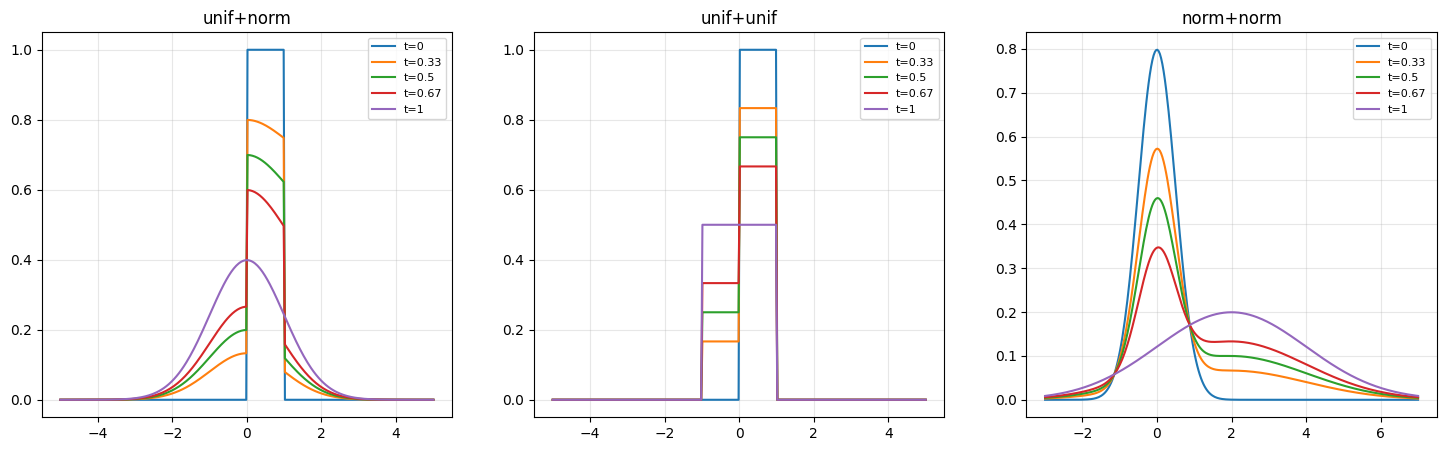

In [45]:
ctx.reset()
ctx.Lx = np.linspace(-5,5,300)

def meas_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for t in ctx.Lt:
        ax.plot(ctx.Lx, (1-t)*f.pdf(ctx.Lx) + t*g.pdf(ctx.Lx), label="t="+str(round(t, 2)))
    ctx.end_axe(ax, name)

meas_inter(ctx, uniform, norm, "unif+norm")
meas_inter(ctx, uniform, uniform(loc=-1, scale=2), "unif+unif")

ctx.Lx = np.linspace(-3,7,300)
meas_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "norm+norm")
plt.show()

[T4]
1. Famille des mesures de Dirac

    Une mesure de Dirac $d_{x_0}$ met un poids 1 sur le point $x_0 \in \mathbb{R}$; or $\eta_t = (1 - t)d_{x_0} + td_{x_1}$ met un poids sur 2 points différents $x_0$ et $x_1$ (or cas trivial ou pour $x_0 = x_1$), donc $\eta_t \notin \mathcal{M}_0$, donc les mesures de Dirac ne sont pas préservées par cette opération d'interpolation.

2. Famille des mesures uniformes
    Pour le même raison que pour les mesures de Dircs, prenons par exemple $\rho_0 = U[0,1]$ et $\rho_1 = U[2,3]$ pour $t = \frac{1}{2}$; $\eta_t = \frac{1}{2}U[0,1] + \frac{1}{2}U[2,3]$ n'est pas une mesure uniforme, car $[0,1]$ et $[2,3]$ sont disjoints. Donc la mesure uniforme n'est pas préservée.

3. Famille des mesures gaussiennes
Soit $\rho_0 = \mathcal{N}(m_0,\sigma_0^2)$ et $\rho_1 = \mathcal{N}(m_1,\sigma_1^2)$.
$\eta_t = (1 - t)\mathcal{N}(m_0,\sigma_0^2) + t \mathcal{N}(m_1,\sigma_1^2)$; étudions la fonction de densité liée à $Y_t \sim \eta_t$ :

$$
f_{Y_t}(x) = (1 - t)\frac{1}{\sqrt{2\pi}\sigma_0} e^{-\frac{(x - m_0)^2}{2\sigma_0^2}} + t\frac{1}{\sqrt{2\pi}\sigma_1} e^{-\frac{(x - m_1)^2}{2\sigma_1^2}}
$$

Or $f_{Y_t}$ n'est clairement pas une fonction de densité de loi gaussienne, comme dans certaine cas elle admetrait de maximum local, donc $\mathcal{M}_0$ n'est pas conservée.

Introduisons maintenant une troisième interpolation, qui consiste à poser, pour $U\sim \mathcal U([0,1])$,
$$
Z_t =(1-t)F^{-1}_0(U) + tF^{-1}_1 (U)
$$
où $F_i$ est la fonction de répartition de $µ_i$ pour $i\in\{0,1\}$. On note $v_t$ la loi de $Z_t$.

[S3] 

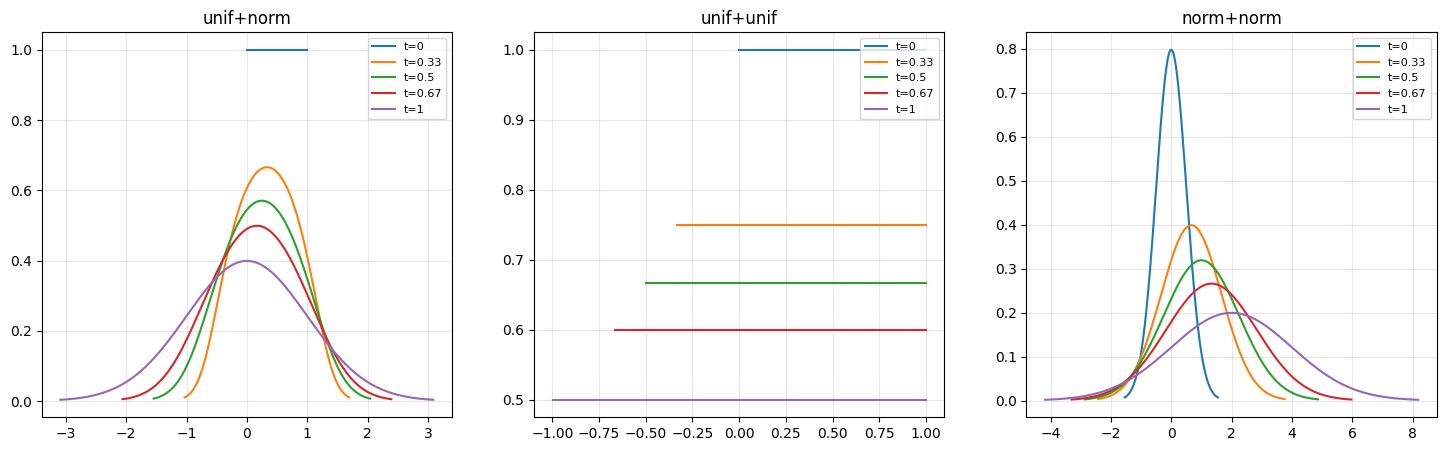

In [46]:
ctx.reset()
ctx.Lx = np.linspace(0, 1, 1002)[1:-1] #uniform space without -inf and +inf

def sim_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for t in ctx.Lt:
        Ly = (1-t)*f.ppf(ctx.Lx)+t*g.ppf(ctx.Lx) # calculating F^{-1}_t
        spline = CubicSpline(Ly, ctx.Lx)         # interpolating F_t
        deriv = spline.derivative()              # approximating f_t = F_t'
        Lx = np.linspace(Ly[0], Ly[-1], 1000)
        ax.plot(Lx, deriv(Lx),label="t="+str(round(t, 2)))
    ctx.end_axe(ax, name)

sim_inter(ctx, uniform, norm, "unif+norm")
sim_inter(ctx, uniform, uniform(loc=-1, scale=2), "unif+unif")
sim_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "norm+norm")
plt.show()

[T5] Regardons la stabilité de certaines classes des mesure
1. Famille des mesures de Dirac

   Pour $\delta_{x_0}$, on a :
  $$
  F_0(x') = \begin{cases}
  0 & \text{si } x' < x_0 \\
  1 & \text{si } x' \geq x_0
  \end{cases}
  $$
  La fonction quantile inverse est donc :
  $$
  F_0^{-1}(u) = \inf\{x\in\mathbb R:F(x)\geq u\}= x_0 \quad \forall u \in ]0,1]
  $$
  Si $\mu_0 = \delta_{x_0}$ et $\mu_1 = \delta_{x_1}$, alors :
  $$
  Z_t = (1-t)x_0 + t x_1
  $$
  La loi de $Z_t$ est donc $\delta_{(1-t)x_0 + t x_1}$. Cette classe est stable.
2. Famille des mesures uniformes
 
   Pour $\mu_0 = \mathcal{U}([a_0, b_0])$, on a :
   $$
  F_0(x') = \frac{x' - a_0}{b_0 - a_0} \quad \text{pour } x' \in [a_0, b_0]
  $$
  La fonction quantile inverse est :
  $$
  F_0^{-1}(u) = a_0 + u(b_0 - a_0) \quad \forall u \in [0,1]
  $$
  Si $\mu_0 = \mathcal{U}([a_0, b_0])$ et $\mu_1 = \mathcal{U}([a_1, b_1])$, alors :
  \begin{align*}
  Z_t &= (1-t)(a_0 + U(b_0 - a_0)) + t(a_1 + U(b_1 - a_1))\\
      &= (1-t)a_0 + t a_1 + U \left[(1-t)(b_0 - a_0) + t(b_1 - a_1)\right]
  \end{align*}
  Comme $U \sim \mathcal{U}([0,1])$, on a :
  $$
  Z_t \sim \mathcal{U}\left([(1-t)a_0 + t a_1, (1-t)b_0 + t b_1]\right)
  $$
  La famille des mesures uniformes est préservée.
3. Famille des mesures gaussiennes
    Pour $\mu_0 = \mathcal{N}(m_0, \sigma_0^2)$, on a :
  $$
  F_0(x) = \Phi\left(\frac{x - m_0}{\sigma_0}\right)
  $$
  où $\Phi$ est la fonction de répartition de $\mathcal{N}(0,1)$. La fonction quantile inverse est :
  $$
  F_0^{-1}(u) = m_0 + \sigma_0 \Phi^{-1}(u) \quad \forall u \in [0,1]
  $$
  Si $\mu_0 = \mathcal{N}(m_0, \sigma_0^2)$ et $\mu_1 = \mathcal{N}(m_1, \sigma_1^2)$, alors :
  \begin{align*}
  Z_t &= (1-t)(m_0 + \sigma_0 \Phi^{-1}(U)) + t(m_1 + \sigma_1 \Phi^{-1}(U))\\
  &= (1-t)m_0 + t m_1 + \left[(1-t)\sigma_0 + t \sigma_1\right] \Phi^{-1}(U)
  \end{align*}
  
  Comme $\Phi^{-1}(U) \sim \mathcal{N}(0,1)$, on a :
  $$
  Z_t \sim \mathcal{N}\left((1-t)m_0 + t m_1, \left[(1-t)\sigma_0 + t \sigma_1\right]^2\right)
  $$

La famille des mesures gaussiennes est préservée.

[T6]
1. Par linéarité $\mathbb E((1-t)X_0+tX_0)= (1-t)\mathbb EX_0 + t\mathbb EX_1$. Pour $η_t = (1−t)µ_0 + tµ_1$ nous avons $\mathbb EX_t=\int xd(t\mu_1+(1-t)\mu_0)=t\int fd\mu_1+(1-t)\int d\mu_0$, car les mesures forme l'éspace dual des fonctions continues à support compact, avec l'action – prendre l'integrale. Et finalement pour $Z_t = (1−t)F^{−1}_0(U)+tF^{−1}_1(U)$ on passe par le même argument que dans le premièr cas, car $F^{-1}_i(U)$ suis le même loi que $X_i$. Alors ces interpolations commute avec $\mathbb E$.

2. Suppoosons que $\mu_0=\mu_1$. Qu'est peut on dit d'interpolations? Dans le première type d'interpolation on utilise le même example que dans [T2] est vois que, $\mu_t\neq\mu_0$. Pour deuxiem methode, on a $\mu=(1-t)\mu_0+t\mu_0=\mu_0$. Est dans troisièm example, on a $F_0 = F_1 =: F$ et donc, on a $F^{-1}(U)=X_t = X_0$, donc on a la même mesure image.

3. Maitenent on verify que la convergence est coninue en loi. C'est evident pour la deuxiem interpolation, en loi
$$
\mathbb Eh(X_t) = (1-t)\mathbb Eh(X_0)+t\mathbb Eh(X_1)
$$
les 2 autres methodes sont continue, comme pour 2 fonctions mesurable $X_0$ et $X_1$ et une fonction continue de support compact $h$, nous avons $h((1-t)X_0(w)+tX_1(w))$ continue en t et $|h|\leq C$ pour une constant $C$ et donc on peut applique theoreme de convergence domminé et voir que
$$
    \mathbb Eh(X_t) = \int h((1-t)X_0(w)+tX_1(w))dw
$$
est continue en $t$.

[S4] Il faut preciser que le choix de $Y_t$ pour $\eta_t$ dans l'exercies $T3$ n'est pas unique est donc en traçons les chemains pour $Y_t$ on ne les trace pas pour $\eta_t$, mais on trace different realisation de $X_t$, $Y_t$, $Z_t$ pour des evenements elementairs $w$, comme c'est démandé dans l'exercis. 

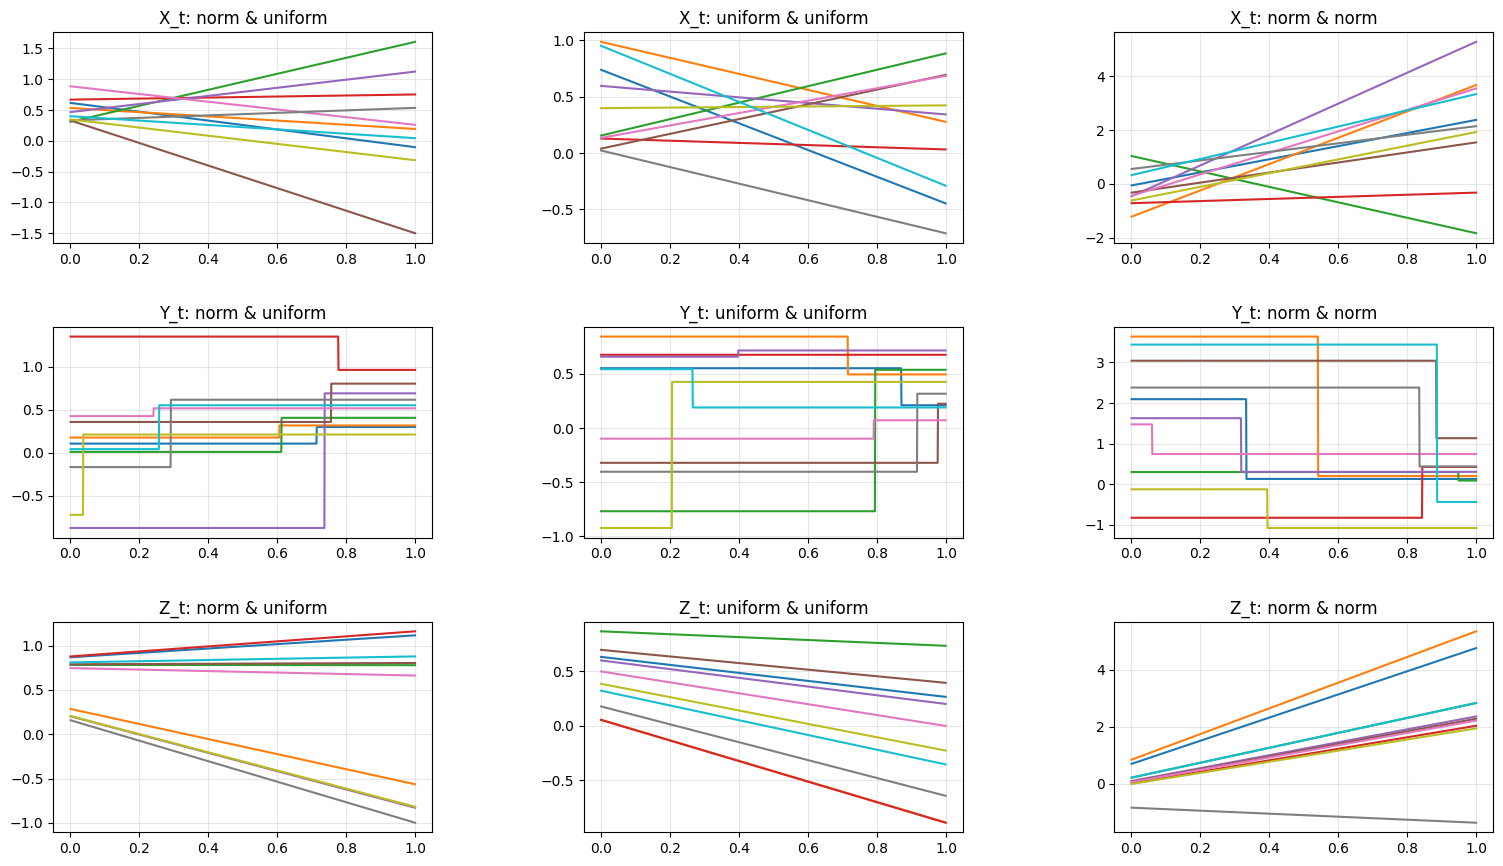

In [49]:
def trace_line(ctx, ax, a, b):
    Ly = (1 - ctx.Lx) * a + ctx.Lx * b
    ax.plot(ctx.Lx, Ly)

def make_10_traj_var_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for i in range(10):
        a, b = f.rvs(), g.rvs()
        trace_line(ctx, ax, a, b)
    ctx.end_axe(ax, name)

def make_10_traj_meas_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for i in range(10):
        u = uniform.rvs()
        a, b = f.rvs(), g.rvs()
        Ly = np.where(u < ctx.Lx, a, b)
        ax.plot(ctx.Lx, Ly)
    ctx.end_axe(ax, name)

def make_10_traj_sim_inter(ctx, f, g, name):
    ax = ctx.next_axe()
    for i in range(10):
        u = uniform.rvs()
        a, b = f.ppf(u), g.ppf(u)
        trace_line(ctx, ax, a, b)
    ctx.end_axe(ax, name)
    
ctx.reset(3,3)
ctx.is_making_legend = False
make_10_traj_var_inter(ctx, uniform, norm, "X_t: norm & uniform")
make_10_traj_var_inter(ctx, uniform, uniform(loc=-1, scale=2), "X_t: uniform & uniform")
make_10_traj_var_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "X_t: norm & norm")

make_10_traj_meas_inter(ctx, uniform, norm, "Y_t: norm & uniform")
make_10_traj_meas_inter(ctx, uniform, uniform(loc=-1, scale=2), "Y_t: uniform & uniform")
make_10_traj_meas_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "Y_t: norm & norm")
    
make_10_traj_sim_inter(ctx, uniform, norm, "Z_t: norm & uniform")
make_10_traj_sim_inter(ctx, uniform, uniform(loc=-1, scale=2), "Z_t: uniform & uniform")
make_10_traj_sim_inter(ctx, norm(scale=0.5), norm(loc=2, scale=2), "Z_t: norm & norm")

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=1.7, wspace=0.4, hspace=0.4)
plt.show()

# 2. Distance de Wasserstein

In [52]:
[T8] 

NameError: name 'T8' is not defined